In [ ]:
from google.colab import files
uploaded = files.upload()

Saving away_team.csv to away_team.csv
Saving event.csv to event.csv
Saving home_team.csv to home_team.csv
Saving tournament.csv to tournament.csv
Saving venue.csv to venue.csv


In [ ]:
import pandas as pd

files = {
    'event': 'event.csv',
    'home_team': 'home_team.csv',
    'away_team': 'away_team.csv',
    'tournament': 'tournament.csv',
}
data = {name: pd.read_csv(path) for name, path in files.items()}

def dedupe_one_per_match(df, id_col='match_id'):
    df = df.drop_duplicates()
    df = df.assign(_null_count=df.isnull().sum(axis=1))
    df = df.sort_values('_null_count').drop_duplicates(subset=id_col, keep='first')
    df = df.drop(columns='_null_count').reset_index(drop=True)
    return df

for name in data:
    data[name] = dedupe_one_per_match(data[name])

**QUESTION6**

In [ ]:
import pandas as pd
import numpy as np

# ---------- gam 1: filter mosabeghate tamoom-shode va motabar ----------
MAX_RANK, MIN_RANK = 2000, 1
DEFAULT_TOURN_POINTS = 1

event = data['event'].copy()
event = event[event['winner_code'].isin([1, 2])]
if 'final_result_only' in event.columns:
    event = event[event['final_result_only'] != True]
print(f"Valid finished matches: {len(event)}")

# ---------- gam 2: paksazi rank va country ----------
home = data['home_team'].copy()
away = data['away_team'].copy()
home['current_rank'] = pd.to_numeric(home['current_rank'], errors='coerce')
away['current_rank'] = pd.to_numeric(away['current_rank'], errors='coerce')

for df_ in [home, away]:
    invalid = df_['current_rank'].isna() | (df_['current_rank'] < MIN_RANK) | (df_['current_rank'] > MAX_RANK)
    df_.loc[invalid, 'current_rank'] = np.nan
    df_['country'] = df_['country'].astype(str).str.strip().str.upper()
    df_.loc[df_['country'].isin(['', 'N/A', 'NA', 'NONE', 'UNKNOWN', 'NAN']), 'country'] = np.nan

# ---------- gam 3: etesale home/away be event ----------
m = event[['match_id', 'winner_code']].merge(
    home[['match_id', 'player_id', 'current_rank', 'country']].rename(
        columns={'player_id': 'home_pid', 'current_rank': 'home_rank', 'country': 'home_country'}),
    on='match_id', how='inner'
).merge(
    away[['match_id', 'player_id', 'current_rank', 'country']].rename(
        columns={'player_id': 'away_pid', 'current_rank': 'away_rank', 'country': 'away_country'}),
    on='match_id', how='inner'
)
m = m[m['home_pid'] != m['away_pid']]
m = m.dropna(subset=['home_rank', 'away_rank', 'home_country', 'away_country'])
print(f"Matches after validity filters: {len(m)}")

# ---------- gam 4: etesale tournament baraye ahamiat ----------
tourn = data['tournament'].drop_duplicates(subset='match_id')[['match_id', 'tennis_points']]
tourn['tennis_points'] = pd.to_numeric(tourn['tennis_points'], errors='coerce')
tourn.loc[tourn['tennis_points'] < 0, 'tennis_points'] = np.nan
tourn['tennis_points'] = tourn['tennis_points'].clip(lower=1).fillna(DEFAULT_TOURN_POINTS)
m = m.merge(tourn, on='match_id', how='left')
m['tennis_points'] = m['tennis_points'].fillna(DEFAULT_TOURN_POINTS)

# ---------- gam 5: mohasebe upset_factor va match_score ----------
m['winner_rank'] = np.where(m['winner_code'] == 1, m['home_rank'], m['away_rank'])
m['loser_rank'] = np.where(m['winner_code'] == 1, m['away_rank'], m['home_rank'])
m['winner_country'] = np.where(m['winner_code'] == 1, m['home_country'], m['away_country'])
m['winner_pid'] = np.where(m['winner_code'] == 1, m['home_pid'], m['away_pid'])

m['upset_factor'] = m['winner_rank'] / m['loser_rank']
m['match_score'] = np.log1p(m['upset_factor']) * np.log1p(m['tennis_points'])

# ---------- gam 6: aggregate dar sathe bazikon, sepas keshvar (bedoone jodakonandegie jensiat) ----------
player_scores = m.groupby(['winner_pid', 'winner_country']).agg(
    total_score=('match_score', 'sum'),
    total_wins=('match_id', 'count'),
    upset_wins=('upset_factor', lambda x: (x > 1).sum())
).reset_index()

country_scores = player_scores.groupby('winner_country').agg(
    total_score=('total_score', 'sum'),
    total_wins=('total_wins', 'sum'),
    upset_wins=('upset_wins', 'sum'),
    active_players=('winner_pid', 'nunique')
).reset_index().sort_values('total_score', ascending=False)

print("\nTop 10 countries:")
print(country_scores.head(10).to_string(index=False))

# ---------- gam 7: OVERALL ANSWER (humanized) ----------
# ---------- OVERALL ANSWER (yek keshvar) ----------
top = country_scores.iloc[0]

print("\n" + "="*75)
print("OVERALL ANSWER")
print("="*75)
print(f"Most successful country : {top['winner_country']}")
print(f"Total wins               : {int(top['total_wins'])}")
print(f"Upset wins               : {int(top['upset_wins'])}")
print(f"Active players            : {int(top['active_players'])}")
print(f"Quality-weighted score    : {top['total_score']:.1f}")

Valid finished matches: 15150
Matches after validity filters: 9135

Top 10 countries:
winner_country  total_score  total_wins  upset_wins  active_players
           USA  1271.291551         755         301             167
        FRANCE   813.286173         820         290             158
         ITALY   687.619365         656         236             160
        RUSSIA   631.814441         498         180             109
     ARGENTINA   541.584552         409         135              81
       GERMANY   443.918413         418         156             100
     AUSTRALIA   427.658848         359         112              72
CZECH REPUBLIC   401.736705         304         103              55
         SPAIN   397.860046         397         156              83
         JAPAN   370.936585         375         136              93

OVERALL ANSWER
Most successful country : USA
Total wins               : 755
Upset wins               : 301
Active players            : 167
Quality-weighted score    

**QUESTION14**

In [ ]:
import pandas as pd

#check krdn group turnoment
consistency_check = data['tournament'].groupby('tournament_id')['ground_type'].nunique()
print(f"Tournaments with inconsistent ground_type: {(consistency_check > 1).sum()}")

#faghat tornoment check kn na match
tournament_level = data['tournament'].drop_duplicates(subset='tournament_id').dropna(subset=['ground_type'])
print(f"Unique tournaments analyzed: {len(tournament_level)}")

#tozie
tour_counts = tournament_level['ground_type'].value_counts()
tour_pct = (tournament_level['ground_type'].value_counts(normalize=True) * 100).round(1)
print(pd.DataFrame({'count': tour_counts, 'pct': tour_pct}))

# overall answer
top_surface, top_count, top_pct = tour_counts.idxmax(), tour_counts.max(), tour_pct.max()
print("\n" + "="*75)
print("OVERALL ANSWER")
print("="*75)
print(f"Most common surface : {top_surface} — {top_count} tournaments ({top_pct}%)")

Tournaments with inconsistent ground_type: 6
Unique tournaments analyzed: 529
                   count   pct
ground_type                   
Hardcourt outdoor    239  45.2
Red clay             183  34.6
Hardcourt indoor      83  15.7
Grass                  8   1.5
Red clay indoor        6   1.1
Carpet indoor          5   0.9
Synthetic outdoor      4   0.8
Green clay             1   0.2

OVERALL ANSWER
Most common surface : Hardcourt outdoor — 239 tournaments (45.2%)


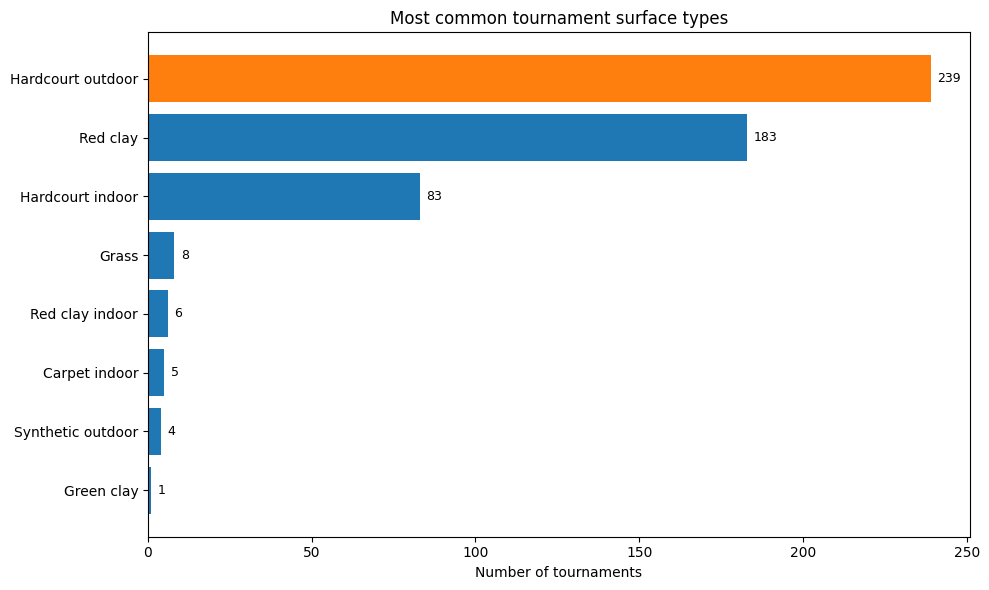

In [ ]:
import matplotlib.pyplot as plt

tournament_level = data['tournament'].drop_duplicates(subset='tournament_id').dropna(subset=['ground_type'])
tour_counts = tournament_level['ground_type'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['tab:orange' if v == tour_counts.max() else 'tab:blue' for v in tour_counts.values]
bars = plt.barh(tour_counts.index, tour_counts.values, color=colors)

for bar, val in zip(bars, tour_counts.values):
    plt.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, str(val),
              va='center', fontsize=9)

plt.xlabel('Number of tournaments')
plt.title('Most common tournament surface types')
plt.tight_layout()
plt.savefig('q14_surface_distribution.png', dpi=150)
plt.show()

**QUESTION3**

In [ ]:
import pandas as pd

# dedupe kamelt (bar asase kamel-tarin radif, na avalin)
def dedupe_one_per_match(df, id_col='match_id'):
    df = df.drop_duplicates()
    df = df.assign(_null_count=df.isnull().sum(axis=1))
    df = df.sort_values('_null_count').drop_duplicates(subset=id_col, keep='first')
    df = df.drop(columns='_null_count').reset_index(drop=True)
    return df

home_c = dedupe_one_per_match(data['home_team'])
away_c = dedupe_one_per_match(data['away_team'])
event_c = dedupe_one_per_match(data['event'])

# faghat mosabeghate ba winner_code motabar
ev = event_c[event_c['winner_code'].isin([1, 2])][['match_id', 'winner_code']]
print(f"Valid matches with winner_code: {len(ev)}")

h = home_c[['match_id', 'player_id', 'name']].rename(columns={'player_id': 'home_pid', 'name': 'home_name'})
a = away_c[['match_id', 'player_id', 'name']].rename(columns={'player_id': 'away_pid', 'name': 'away_name'})

# LEFT merge (na inner) taa mosabeghate ba yek taraf gomshode az dast nare
dfw = ev.merge(h, on='match_id', how='left').merge(a, on='match_id', how='left')
print(f"Missing home player info: {dfw['home_pid'].isnull().sum()}")
print(f"Missing away player info: {dfw['away_pid'].isnull().sum()}")

# shomareshe barde har taraf be soorate jodagane
home_wins = (dfw[dfw['winner_code'] == 1].dropna(subset=['home_pid'])
             .groupby(['home_pid', 'home_name']).size().reset_index(name='wins')
             .rename(columns={'home_pid': 'player_id', 'home_name': 'name'}))

away_wins = (dfw[dfw['winner_code'] == 2].dropna(subset=['away_pid'])
             .groupby(['away_pid', 'away_name']).size().reset_index(name='wins')
             .rename(columns={'away_pid': 'player_id', 'away_name': 'name'}))

# jam zadan har do taraf
total_wins = (pd.concat([home_wins, away_wins])
              .groupby(['player_id', 'name'])['wins'].sum()
              .reset_index().sort_values('wins', ascending=False))

# OVERALL ANSWER
top = total_wins.iloc[0]
print("\n" + "="*75)
print("OVERALL ANSWER")
print("="*75)
print(f"Player with most wins : {top['name']}")
print(f"Player ID              : {int(top['player_id'])}")
print(f"Number of wins          : {int(top['wins'])}")

Valid matches with winner_code: 16266
Missing home player info: 4237
Missing away player info: 4926

OVERALL ANSWER
Player with most wins : Popko D.
Player ID              : 50901
Number of wins          : 30
